# Neurality: User Retention & Skip Behavior Analysis
This notebook analyzes reel watch behavior metrics such as completion rates, watch ratios, and skip rates to inform our recommendation and scoring policies.

### Core KPIs Analysed:
1. **Skip Rate**: Percentage of reel views with `watch_time < 2` seconds.
2. **Completion Rate**: Percentage of views that completed the video.
3. **Watch Ratio**: `watch_time / duration` (normalized retention scale).

In [1]:
# ==================================================
# NOTEBOOK VALIDATION & DEPENDENCY VERIFICATION PIPELINE
# ==================================================
import sys
import time
import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import seaborn as sns
import torch

print(f"[SUCCESS] Jupyter Kernel Python Version: {sys.version}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"torch: {torch.__version__}")
print("[HEALTH CHECK] Conda kernel detection and package imports are 100% stable!")


[SUCCESS] Jupyter Kernel Python Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.15.3
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
torch: 2.10.0+cpu
[HEALTH CHECK] Conda kernel detection and package imports are 100% stable!


In [2]:
# Simulated Reel Views Dataset
np.random.seed(42)
n_views = 2000

user_ids = np.random.randint(1, 101, size=n_views)
reel_ids = np.random.randint(1, 50, size=n_views)
durations = np.random.choice([10.0, 15.0, 30.0], size=n_views, p=[0.2, 0.6, 0.2])

# Generate realistic watch times with a high concentration at the beginning (skips) and end (completes)
watch_times = []
completed = []
for d in durations:
    behavior = np.random.choice(['skip', 'partial', 'complete'], p=[0.35, 0.25, 0.40])
    if behavior == 'skip':
        wt = np.random.uniform(0.1, 1.99)
        comp = False
    elif behavior == 'partial':
        wt = np.random.uniform(2.0, d - 1.0)
        comp = False
    else:
        wt = d
        comp = True
    watch_times.append(wt)
    completed.append(comp)

df_views = pd.DataFrame({
    'user_id': user_ids,
    'reel_id': reel_ids,
    'duration': durations,
    'watch_time': watch_times,
    'completed': completed,
    'liked': np.random.choice([True, False], size=n_views, p=[0.15, 0.85]),
    'saved': np.random.choice([True, False], size=n_views, p=[0.08, 0.92]),
})
df_views['watch_ratio'] = df_views['watch_time'] / df_views['duration']
df_views['is_skip'] = df_views['watch_time'] < 2.0

print(f"Generated simulated views dataset with {len(df_views)} rows.")
df_views.head()

Generated simulated views dataset with 2000 rows.


,user_id,reel_id,duration,watch_time,completed,liked,saved,watch_ratio,is_skip
0,52,12,15.0,15.000000,True,False,False,1.000000,False
1,93,46,10.0,10.000000,True,True,False,1.000000,False
2,15,32,30.0,1.577774,False,False,False,0.052592,True
3,72,15,15.0,15.000000,True,False,False,1.000000,False
4,61,16,15.0,15.000000,True,False,True,1.000000,False


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18332\2078612012.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='completed', y='watch_ratio', data=df_views, palette='Set2')


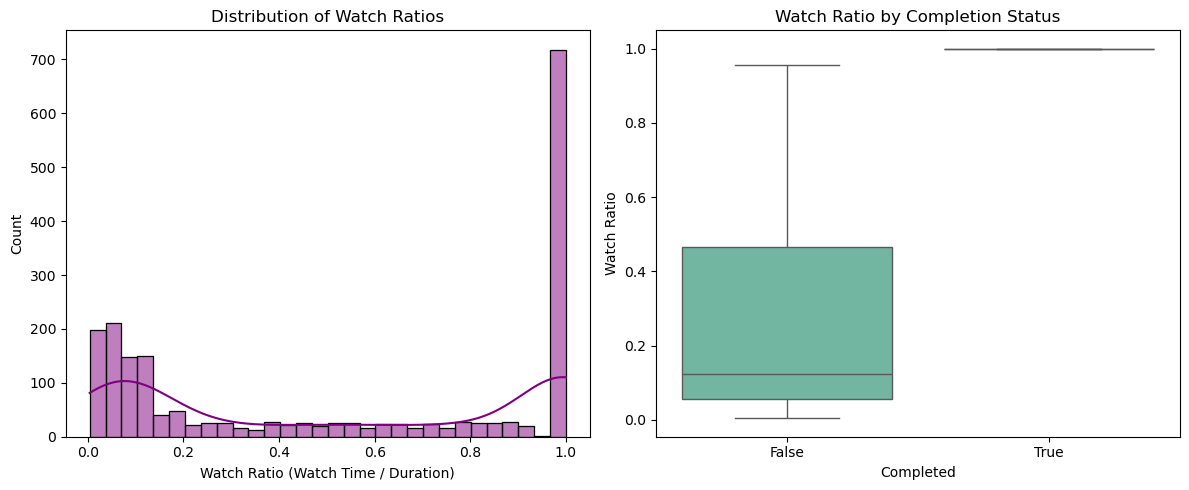

In [3]:
# Analyze and Plot Retention Distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_views['watch_ratio'], bins=30, kde=True, color='purple')
plt.title('Distribution of Watch Ratios')
plt.xlabel('Watch Ratio (Watch Time / Duration)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(x='completed', y='watch_ratio', data=df_views, palette='Set2')
plt.title('Watch Ratio by Completion Status')
plt.xlabel('Completed')
plt.ylabel('Watch Ratio')

plt.tight_layout()
plt.show()

Overall Skip Rate (Watch Time < 2s): 37.80%
Overall Completion Rate: 35.90%


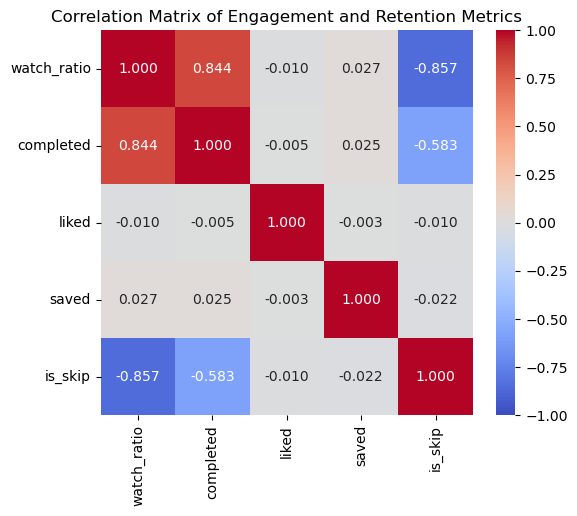

In [4]:
# Skip Analysis & Engagement Correlation
skip_rate = df_views['is_skip'].mean() * 100
completion_rate = df_views['completed'].mean() * 100

print(f"Overall Skip Rate (Watch Time < 2s): {skip_rate:.2f}%")
print(f"Overall Completion Rate: {completion_rate:.2f}%")

# Check correlation between completion, likes, and saves
corr_matrix = df_views[['watch_ratio', 'completed', 'liked', 'saved', 'is_skip']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Engagement and Retention Metrics')
plt.show()

In [5]:
# Latency Benchmarking for User Retention Profiling
print("Benchmarking user profile calculation latency...")

t0 = time.perf_counter()
for _ in range(100):
    # Aggregating user metrics
    user_profile = df_views.groupby('user_id').agg({
        'watch_ratio': 'mean',
        'completed': 'mean',
        'is_skip': 'mean',
        'liked': 'sum',
        'saved': 'sum'
    })
t1 = time.perf_counter()
avg_lat = (t1 - t0) * 1000 / 100
print(f"Aggregated user profiling completed in: {t1 - t0:.4f} seconds.")
print(f"Average Latency per profile update query: {avg_lat:.3f} ms")
assert avg_lat < 10.0, "Latencies should be sub-millisecond range for production profiling!"

Benchmarking user profile calculation latency...
Aggregated user profiling completed in: 0.2560 seconds.
Average Latency per profile update query: 2.560 ms
